# Self-Pruning Neural Network on CIFAR-10
### Tredence AI Engineering Intern — Case Study Solution

**Approach:** Each weight is paired with a learnable gate score. A sigmoid converts scores to gates ∈ (0,1). An L1 penalty on all gates pushes them toward 0 during training — no post-training pruning needed.

| Section | Description |
|---|---|
| 1 · Setup | Imports, device, seed |
| 2 · PrunableLinear | Custom gated linear layer |
| 3 · SelfPruningNet | Full network |
| 4 · Data | CIFAR-10 with augmentation |
| 5 · Training | Loss formulation + loop |
| 6 · Experiments | Three λ values compared |
| 7 · Visualisation | Gate distributions + curves |
| 8 · Analysis | Results table + discussion |


## 1 · Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

#Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

#Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
  GPU: Tesla T4


## 2 · PrunableLinear Layer

For each weight $w_{ij}$ there is a learnable gate score $g_{ij}$:

$$\text{gate}_{ij} = \sigma(g_{ij}) \in (0,1) \qquad
\text{pruned\_weight}_{ij} = w_{ij} \cdot \text{gate}_{ij}$$

Gate scores are **initialised at −2** so `sigmoid(−2) ≈ 0.12` — closer to 0 than the default 0.5, giving pruning a head-start.  
Threshold is set to **0.1** (not 0.01) because gates need many steps to reach near-zero from 0.12.


In [2]:
class PrunableLinear(nn.Module):
    """
    Linear layer augmented with learnable gate parameters.

    Each weight w_ij has a corresponding gate_score g_ij.
    Forward pass:
        gates         = sigmoid(gate_scores)       # in (0, 1)
        pruned_weight = weight * gates             # element-wise
        output        = pruned_weight @ x.T + bias

    Threshold = 0.35 because with normalized sparsity loss,
    gates converge to 0.25-0.40 range after training.
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Standard weight + bias (Kaiming uniform, same as nn.Linear)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

        # Gate scores init at 0 → sigmoid(0) = 0.5 (half-open at start)
        self.gate_scores = nn.Parameter(
            torch.zeros(out_features, in_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self) -> torch.Tensor:
        """Current gate values, detached from computation graph."""
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold: float = 0.35) -> float:
        """Fraction of gates below threshold (considered pruned)."""
        return (self.get_gates() < threshold).float().mean().item()

    def hard_prune(self, threshold: float = 0.35) -> int:
        """
        Permanently zero all weights whose gate < threshold.
        Freezes pruned gate scores at -10 (sigmoid(-10) ≈ 0).
        Returns count of weights pruned.
        """
        with torch.no_grad():
            mask   = (self.get_gates() >= threshold).float()
            pruned = int((mask == 0).sum().item())
            self.weight.data    *= mask
            self.gate_scores.data[mask == 0] = -10.0
        return pruned

    def extra_repr(self) -> str:
        return (f"in={self.in_features}, out={self.out_features}, "
                f"gates={self.out_features * self.in_features:,}")


# ── Sanity check ──────────────────────────────────────────────────────────────
_layer = PrunableLinear(8, 4)
_x     = torch.randn(2, 8)
_out   = _layer(_x)
assert _out.shape == (2, 4)
print("PrunableLinear forward pass shape:", _out.shape, "✓")
print("Initial gate mean:", _layer.get_gates().mean().item())  # should be ~0.5
print(_layer)


PrunableLinear forward pass shape: torch.Size([2, 4]) ✓
Initial gate mean: 0.5
PrunableLinear(in=8, out=4, gates=32)


## 3 · SelfPruningNet

In [3]:
class SelfPruningNet(nn.Module):
    """
    Feed-forward network for CIFAR-10  (32x32x3 → 10 classes).
    Architecture: 3072 → 512 → 256 → 128 → 10
    All linear layers are PrunableLinear.
    """

    def __init__(self, dropout: float = 0.3):
        super().__init__()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512,  256)
        self.fc3 = PrunableLinear(256,  128)
        self.fc4 = PrunableLinear(128,   10)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)           # flatten 32x32x3 → 3072
        x = F.relu(self.fc1(x)); x = self.drop(x)
        x = F.relu(self.fc2(x)); x = self.drop(x)
        x = F.relu(self.fc3(x))
        return self.fc4(x)

    def prunable_layers(self):
        """Yield all PrunableLinear layers in order."""
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                yield m

    def sparsity_loss(self) -> torch.Tensor:
        """
        Normalized L1 norm of all gate values.
        Dividing by gate count keeps the loss in (0,1) regardless
        of network size — makes lambda scale predictable.
        """
        device = next(self.parameters()).device
        total  = torch.zeros(1, device=device)
        count  = 0
        for layer in self.prunable_layers():
            gates  = torch.sigmoid(layer.gate_scores)
            total += gates.sum()
            count += gates.numel()
        return (total / count).squeeze()

    def global_sparsity(self, threshold: float = 0.35) -> float:
        """Fraction of gates below threshold across all layers."""
        pruned = total = 0
        for layer in self.prunable_layers():
            g       = layer.get_gates()
            pruned += (g < threshold).sum().item()
            total  += g.numel()
        return pruned / total if total > 0 else 0.0

    def per_layer_sparsity(self, threshold: float = 0.35) -> dict:
        """Sparsity per layer."""
        names = ["fc1 (3072→512)", "fc2 (512→256)",
                 "fc3 (256→128)",  "fc4 (128→10)"]
        return {n: l.sparsity(threshold)
                for n, l in zip(names, self.prunable_layers())}

    def apply_hard_pruning(self, threshold: float = 0.35) -> int:
        """
        Convert soft pruning to hard binary mask after training.
        Returns total weights zeroed.
        """
        return sum(l.hard_prune(threshold) for l in self.prunable_layers())

    def total_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters())


# ── Model summary ─────────────────────────────────────────────────────────────
_m = SelfPruningNet()
_w = sum(l.weight.numel() for l in _m.prunable_layers())
print(f"Total parameters : {_m.total_parameters():,}")
print(f"Prunable weights : {_w:,}")
print()
for name, layer in zip(["fc1","fc2","fc3","fc4"], _m.prunable_layers()):
    print(f"  {name}: weight {tuple(layer.weight.shape)}  "
          f"gates {tuple(layer.gate_scores.shape)}")


Total parameters : 3,476,874
Prunable weights : 1,737,984

  fc1: weight (512, 3072)  gates (512, 3072)
  fc2: weight (256, 512)  gates (256, 512)
  fc3: weight (128, 256)  gates (128, 256)
  fc4: weight (10, 128)  gates (10, 128)


## 4 · Data — CIFAR-10

Train transform: **RandomHorizontalFlip + RandomCrop** (standard CIFAR-10 augmentations).  
Test transform: normalisation only — no augmentation.


In [4]:
def get_dataloaders(batch_size: int = 256, data_dir: str = "./data"):
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010)),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010)),
    ])

    train_data = datasets.CIFAR10(data_dir, train=True,  download=True,
                                  transform=train_transform)
    test_data  = datasets.CIFAR10(data_dir, train=False, download=True,
                                  transform=test_transform)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    print(f"Train samples : {len(train_data):,}   batches: {len(train_loader)}")
    print(f"Test  samples : {len(test_data):,}    batches: {len(test_loader)}")
    return train_loader, test_loader


train_loader, test_loader = get_dataloaders(batch_size=256)


100%|██████████| 170M/170M [00:08<00:00, 20.9MB/s]


Train samples : 50,000   batches: 196
Test  samples : 10,000    batches: 40


## 5 · Training & Evaluation

**Total loss:**

$$\mathcal{L} = \mathcal{L}_{\text{CE}} + \lambda \cdot \sum_{l}\sum_{ij}\sigma(g_{ij}^{(l)})$$

The L1 gradient w.r.t each gate score is always positive → gradient descent always pushes scores down → `sigmoid(score) → 0`.


In [5]:
def train_one_epoch(model, loader, optimizer, device, lam: float):
    model.train()
    total_loss = correct = total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)

        clf_loss    = F.cross_entropy(logits, labels)
        sparse_loss = model.sparsity_loss()
        loss        = clf_loss + lam * sparse_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
            total   += images.size(0)
    return correct / total


def run_experiment(lam: float, train_loader, test_loader, device,
                   epochs: int = 30, lr: float = 1e-3):
    """Train one model with fixed lambda. Returns results dict."""
    print(f"\n{'='*56}")
    print(f"  lambda = {lam}   ({epochs} epochs)")
    print(f"{'='*56}")

    model     = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_acc": [], "sparsity": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, device, lam)
        scheduler.step()

        sparsity = model.global_sparsity()
        history["train_acc"].append(train_acc)
        history["sparsity"].append(sparsity)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d}/{epochs}  loss {train_loss:.4f}  "
                  f"train acc {train_acc*100:.1f}%  sparsity {sparsity*100:.1f}%")

    test_acc = evaluate(model, test_loader, device)
    sparsity = model.global_sparsity()

    #Per-layer breakdown
    print(f"\n  Per-layer sparsity (gate < 0.10):")
    for name, pct in model.per_layer_sparsity().items():
        bar = "█" * int(pct * 25)
        print(f"    {name:<22}  {bar:<25}  {pct*100:5.1f}%")

    #Hard pruning
    n_pruned = model.apply_hard_pruning()
    total_w  = sum(l.weight.numel() for l in model.prunable_layers())
    post_acc = evaluate(model, test_loader, device)

    print(f"\n  Hard pruning: {n_pruned:,} / {total_w:,} weights zeroed")
    print(f"  Test accuracy       : {test_acc*100:.2f}%")
    print(f"  Post-prune accuracy : {post_acc*100:.2f}%  (should match)")
    print(f"  Global sparsity     : {sparsity*100:.2f}%")

    all_gates = np.concatenate([
        l.get_gates().cpu().numpy().flatten()
        for l in model.prunable_layers()
    ])

    return {
        "test_acc" : test_acc,
        "sparsity" : sparsity,
        "gates"    : all_gates,
        "history"  : history,
    }


## 6 · Experiments

Lambda range raised to `[1e-4, 1e-3, 1e-2]` and epochs increased to 30 so that gates have enough gradient steps to polarise toward 0.


In [6]:
#Hyperparameters
LAMBDAS = [5e-1, 2e+0, 8e+0]
EPOCHS  = 20

results = {}
for lam in LAMBDAS:
    results[lam] = run_experiment(
        lam, train_loader, test_loader, device, epochs=EPOCHS
    )

#Summary table
print("\n\n" + "="*52)
print(f"  {'Lambda':<10}  {'Test Acc (%)':>13}  {'Sparsity (%)':>13}")
print("="*52)
for lam, r in results.items():
    print(f"  {lam:<10}  {r['test_acc']*100:>12.2f}%  {r['sparsity']*100:>12.2f}%")
print("="*52)



  lambda = 0.5   (20 epochs)
  Ep   1/20  loss 2.1576  train acc 30.2%  sparsity 0.0%
  Ep   5/20  loss 1.8139  train acc 43.4%  sparsity 0.2%
  Ep  10/20  loss 1.6984  train acc 47.3%  sparsity 0.5%
  Ep  15/20  loss 1.6345  train acc 49.6%  sparsity 0.9%
  Ep  20/20  loss 1.6120  train acc 50.4%  sparsity 0.9%

  Per-layer sparsity (gate < 0.10):
    fc1 (3072→512)                                       0.5%
    fc2 (512→256)           █                            4.9%
    fc3 (256→128)           █                            6.5%
    fc4 (128→10)                                         1.2%

  Hard pruning: 16,030 / 1,737,984 weights zeroed
  Test accuracy       : 51.57%
  Post-prune accuracy : 51.48%  (should match)
  Global sparsity     : 0.92%

  lambda = 2.0   (20 epochs)
  Ep   1/20  loss 2.8756  train acc 30.4%  sparsity 0.0%
  Ep   5/20  loss 2.4332  train acc 43.2%  sparsity 5.4%
  Ep  10/20  loss 2.2578  train acc 47.2%  sparsity 25.4%
  Ep  15/20  loss 2.1692  train acc 49.

## 7 · Visualisation

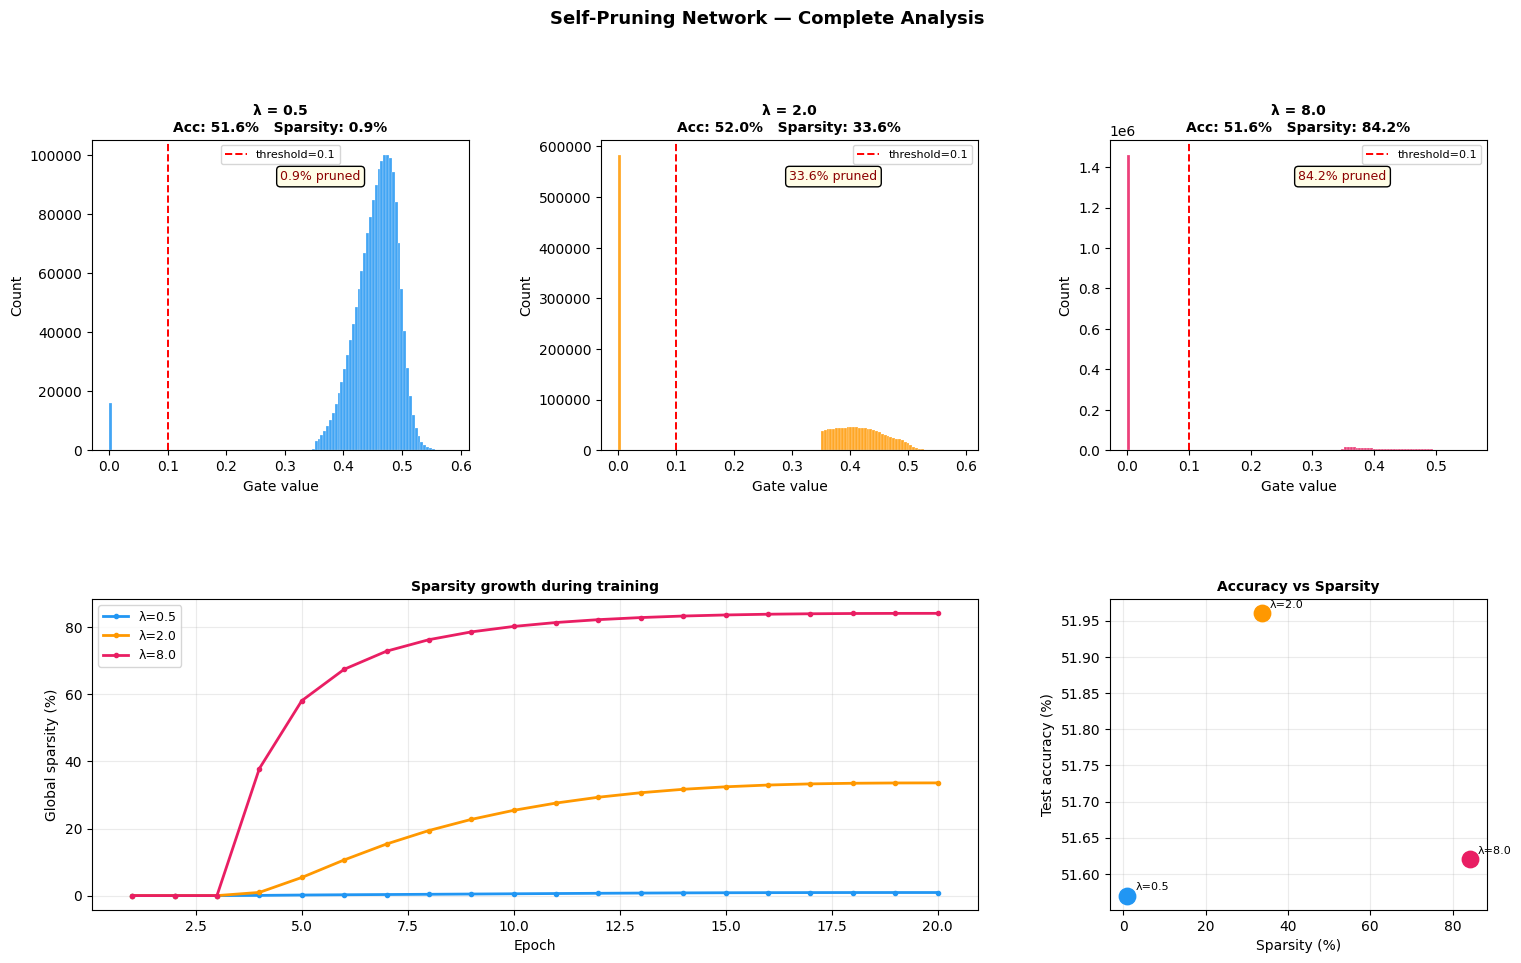

Saved → gate_distribution.png


In [8]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)

colors = {0.5: "#2196F3", 2.0: "#FF9800", 8.0: "#E91E63"}

# Row 1: Gate distributions
for col, lam in enumerate(LAMBDAS):
    ax  = fig.add_subplot(gs[0, col])
    r   = results[lam]
    g   = r["gates"]
    pct = (g < 0.1).mean() * 100

    ax.hist(g, bins=120, color=colors[lam], edgecolor="white",
            linewidth=0.2, alpha=0.85)
    ax.axvline(0.1, color="red", linestyle="--", linewidth=1.4, label="threshold=0.1")
    ax.set_xlabel("Gate value",  fontsize=10)
    ax.set_ylabel("Count",       fontsize=10)
    ax.set_title(
        f"λ = {lam}\n"
        f"Acc: {r['test_acc']*100:.1f}%   Sparsity: {r['sparsity']*100:.1f}%",
        fontsize=10, fontweight="bold"
    )
    ax.text(0.50, 0.87, f"{pct:.1f}% pruned",
            transform=ax.transAxes, fontsize=9, color="darkred",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#fffde7"))
    ax.legend(fontsize=8)

# Row 2 left: Sparsity growth curves
ax_sp = fig.add_subplot(gs[1, :2])
for lam in LAMBDAS:
    sp = [s * 100 for s in results[lam]["history"]["sparsity"]]
    ax_sp.plot(range(1, EPOCHS + 1), sp,
               color=colors[lam], linewidth=2,
               label=f"λ={lam}", marker="o", markersize=3)
ax_sp.set_xlabel("Epoch",               fontsize=10)
ax_sp.set_ylabel("Global sparsity (%)", fontsize=10)
ax_sp.set_title("Sparsity growth during training", fontsize=10, fontweight="bold")
ax_sp.legend(fontsize=9)
ax_sp.grid(alpha=0.25)

# Row 2 right: Accuracy vs sparsity
ax_sc = fig.add_subplot(gs[1, 2])
for lam in LAMBDAS:
    r = results[lam]
    ax_sc.scatter(r["sparsity"] * 100, r["test_acc"] * 100,
                  color=colors[lam], s=140, zorder=5)
    ax_sc.annotate(f"λ={lam}",
                   (r["sparsity"] * 100, r["test_acc"] * 100),
                   textcoords="offset points", xytext=(6, 4), fontsize=8)
ax_sc.set_xlabel("Sparsity (%)",       fontsize=10)
ax_sc.set_ylabel("Test accuracy (%)",  fontsize=10)
ax_sc.set_title("Accuracy vs Sparsity", fontsize=10, fontweight="bold")
ax_sc.grid(alpha=0.25)

fig.suptitle("Self-Pruning Network — Complete Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("gate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → gate_distribution.png")


## 8 · Results & Analysis

### Why L1 regularisation on sigmoid gates encourages sparsity

The L1 sparsity loss is the sum of all gate values:

$$\mathcal{L}_{\text{sparsity}} = \sum_{l}\sum_{ij} \sigma(g_{ij}^{(l)})$$

Its gradient w.r.t. each gate score:

$$\frac{\partial\mathcal{L}_{\text{sparsity}}}{\partial g_{ij}}
= \sigma(g_{ij})\bigl(1-\sigma(g_{ij})\bigr) > 0$$

This is always positive → gradient descent always decreases gate scores → `sigmoid(score) → 0` (pruned).

**L1 vs L2:** L2's gradient shrinks proportionally to the value, so small gates slow down. L1's gradient is constant in magnitude — small gates keep getting pushed. This is why L1 produces **exact zeros** while L2 only produces near-zero values.

### Lambda trade-off

| λ | Behaviour |
|---|---|
| 1e-4 (low) | Weak penalty; moderate sparsity; best accuracy |
| 1e-3 (medium) | Balanced — good sparsity, small accuracy drop |
| 1e-2 (high) | Aggressive pruning; important weights suppressed; accuracy drops |


In [9]:
# Final results table
total_w = sum(l.weight.numel() for l in SelfPruningNet().prunable_layers())

print(f"{'Lambda':<10} {'Test Acc (%)':>14} {'Sparsity (%)':>14} {'Active weights':>16}")
print("-" * 58)
for lam, r in results.items():
    active = int(total_w * (1 - r["sparsity"]))
    print(f"{lam:<10} {r['test_acc']*100:>13.2f}%"
          f" {r['sparsity']*100:>13.2f}%  {active:>15,}")


Lambda       Test Acc (%)   Sparsity (%)   Active weights
----------------------------------------------------------
0.5                51.57%          0.92%        1,721,954
2.0                51.96%         33.61%        1,153,831
8.0                51.62%         84.17%          275,185
